In [4]:
import pandas as pd
import pm4py 

In [18]:
sepsis_log=pm4py.read_xes("./Data/sepsis/sepsis.xes")

ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
parsing log, completed traces :: 100%|██████████| 1050/1050 [00:01<00:00, 896.87it/s]


In [11]:
date_ours="02-25-2026_12-28-00"
date_baseline="02-25-2026_12-31-52"

In [16]:
def returnPrototype(log, route):
    prot=pd.read_csv(route)
    prot=log[log["case:concept:name"]==prot["case:concept:name"][0]]
    sequence=prot["concept:name"]
    return prot, sequence

In [19]:
our_prot_sirs_false, sequence_our_prot_sirs_false=returnPrototype(sepsis_log, "./results/Ours/sepsis/"+date_ours+"/best_predicted_instance_classSIRS-False.csv" )

In [20]:
sequence_our_prot_sirs_false

10408     ER Registration
10409           ER Triage
10410    ER Sepsis Triage
Name: concept:name, dtype: object

In [21]:
our_prot_sirs_true, sequence_our_prot_sirs_true=returnPrototype(sepsis_log, "./results/Ours/sepsis/"+date_ours+"/best_predicted_instance_classSIRS-True.csv" )

In [22]:
sequence_our_prot_sirs_true

6147     ER Registration
6148           ER Triage
6149    ER Sepsis Triage
6150                 CRP
6151          Leucocytes
6152      IV Antibiotics
Name: concept:name, dtype: object

In [ ]:
pd.read_csv("./results/length_prot/sepsis/"+date_baseline+"/medoid_class_SIRS-False.csv")["concept:name"]

0     ER Registration
1           ER Triage
2    ER Sepsis Triage
3                 CRP
4        Admission NC
5        Admission NC
6           Release A
7           Return ER
Name: concept:name, dtype: object

In [ ]:
pd.read_csv("./results/length_prot/sepsis/"+date_baseline+"/medoid_class_SIRS-True.csv")["concept:name"]

0      ER Registration
1            ER Triage
2     ER Sepsis Triage
3                  CRP
4           LacticAcid
5           Leucocytes
6            IV Liquid
7       IV Antibiotics
8         Admission NC
9         Admission NC
10                 CRP
11                 CRP
12          Leucocytes
13          Leucocytes
14                 CRP
15        Admission NC
16           Release A
Name: concept:name, dtype: object

In [1]:
##########################################################################################

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [6]:
def load_training_data(rules_dir):
    dataset=pd.read_csv(rules_dir,index_col=0)
    dataset=dataset.set_index("case:concept:name")

    X=dataset.drop(columns=["Class"])

    y=dataset['Class']
    print("No. of features:"+str(len(X.columns)))

    le = LabelEncoder()
    y_transformed = le.fit_transform(y)
    le_name_mapping = pd.Series(dict(zip(le.classes_,le.transform(le.classes_))))
    X_train_and_validation, X_test, y_train_and_validation, y_test = train_test_split(X,
                                                                                      y_transformed,
                                                                                      test_size=0.2,
                                                                                      stratify=y_transformed,
                                                                                      shuffle=True,
                                                                                      random_state=0)
    
    X_train, X_validation, y_train, y_validation = train_test_split(X_train_and_validation,
                                                                y_train_and_validation,
                                                                test_size=0.2,
                                                                stratify=y_train_and_validation,
                                                                shuffle=True,
                                                                random_state=0)
    return X_train, y_train, le_name_mapping

In [7]:
X_train_sepsis, y_train_sepsis, le_name_mapping=load_training_data("./Data/sepsis/mined_sepsis_confidences_SIRS2OrMore.csv")

No. of features:4704


In [8]:
from SHAP_utils import calculateSHAP_values

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [9]:
import joblib

In [12]:
clf=joblib.load("./results/Ours/sepsis/"+date_ours+"/clf_val0.2.joblib")

In [14]:
shap_values, explainer=calculateSHAP_values(clf, X_train_sepsis)

In [44]:
case_id_prot_false=our_prot_sirs_false["case:concept:name"].unique()[0]
case_id_prot_true=our_prot_sirs_true["case:concept:name"].unique()[0]

In [38]:
len(shap_values)

672

In [30]:
import shap

In [39]:
explainer.expected_value

1.7878482

In [40]:
def plotTop10features(shap_values, case, X, explainer):
    #modified version when the classification is performed for two classes
    index_instance_class=X.index.get_indexer([case])[0]
    shap_values_best_instance=shap_values[index_instance_class]
    expected_value=explainer.expected_value
    class_instance_all_values=X.loc[case]
    shap.waterfall_plot(shap.Explanation(values=shap_values_best_instance, 
                                     base_values=expected_value, 
                                     data=class_instance_all_values),
                                     max_display=10,
                                     show=True)

In [41]:
le_name_mapping

SIRS-False    0
SIRS-True     1
dtype: int32

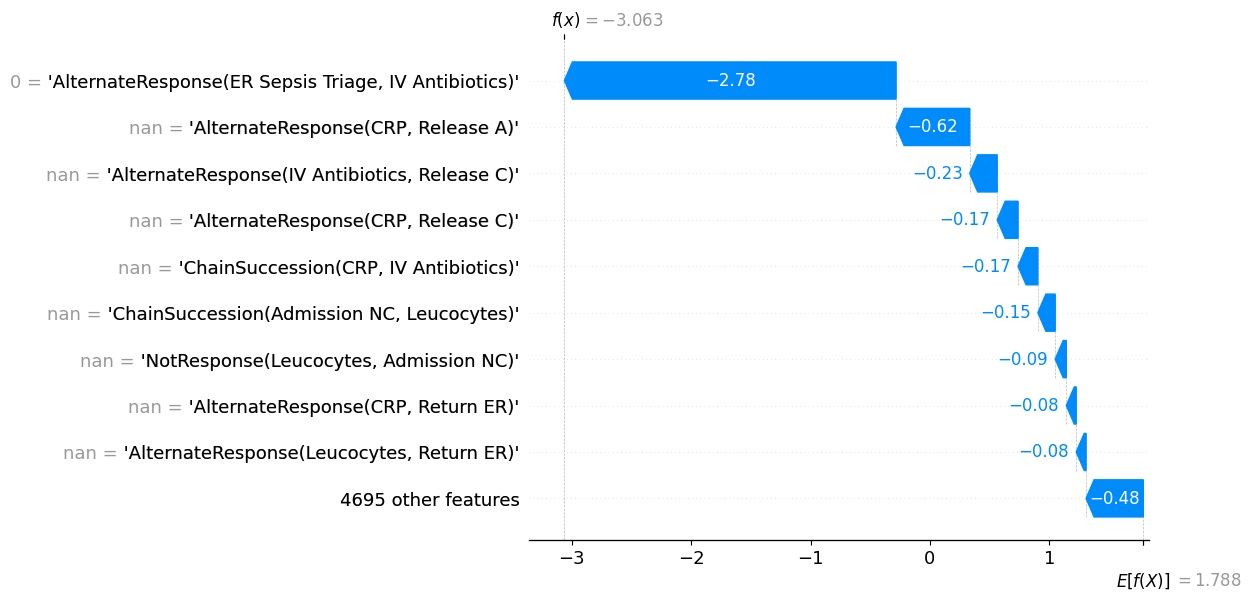

In [43]:
plotTop10features(shap_values=shap_values,
                  case=case_id_prot_false,
                  X=X_train_sepsis,
                  explainer=explainer)

In [46]:
sequence_our_prot_sirs_true

6147     ER Registration
6148           ER Triage
6149    ER Sepsis Triage
6150                 CRP
6151          Leucocytes
6152      IV Antibiotics
Name: concept:name, dtype: object

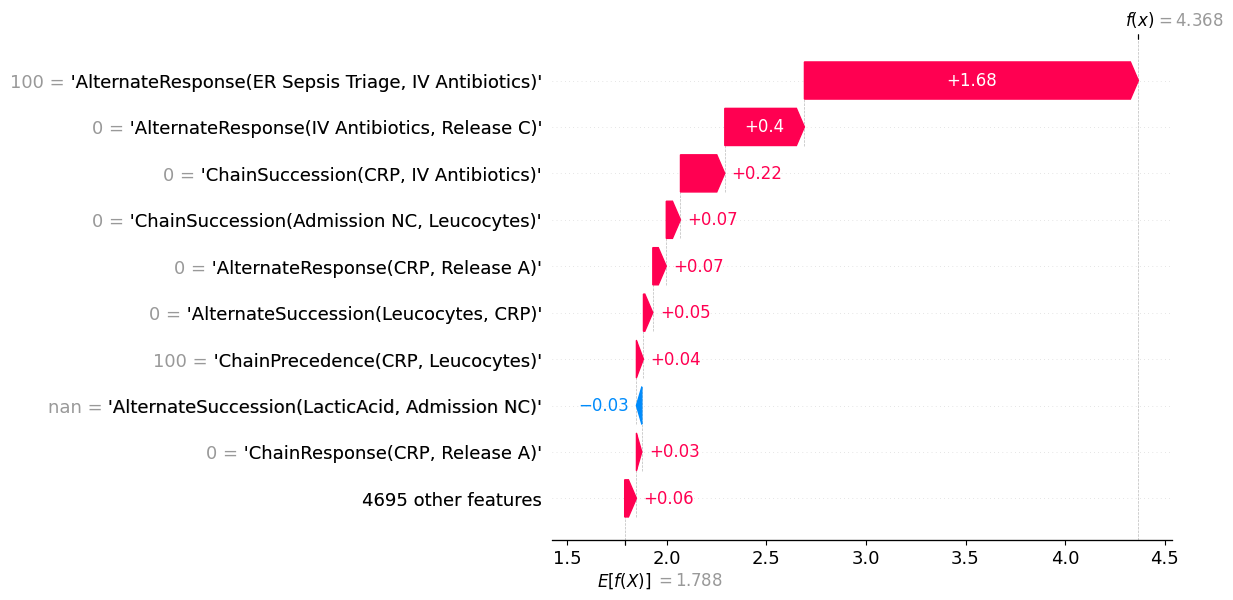

In [45]:
plotTop10features(shap_values=shap_values,
                  case=case_id_prot_true,
                  X=X_train_sepsis,
                  explainer=explainer)